# Predicción de la resistencia a la compresión del cemento

Este notebook construye, paso a paso, un modelo que predice la resistencia a la compresión del cemento a partir de su composición química y de proceso, usando datos reales de control de calidad de planta.

El objetivo no es solo entrenar un modelo. Es sostener con evidencia cada decisión: qué tan temprano puede alertar el modelo, qué variables tiene sentido usar como predictoras y cuáles son en realidad otra medición del mismo resultado, y por qué el checklist final puede afirmar, con aserciones que corren de verdad, que no hay fuga de datos entre entrenamiento y prueba.

Proyecto de ATLAS, el laboratorio de proyectos de FuzzyFrog.AI.

Artículo completo, con cada decisión explicada y su alternativa: [https://fuzzyfrog.ai/es/ai-lab/proyectos/industria/prediccion-resistencia-cemento/](https://fuzzyfrog.ai/es/ai-lab/proyectos/industria/prediccion-resistencia-cemento/)


**Este notebook se corrió y probó de principio a fin el 25 de septiembre de 2026.** Si algo falla o encuentras un error, es probable que una librería, una API o el propio entorno de Colab haya cambiado desde entonces. Escríbenos y lo corregimos.

## Qué vas a aprender

- A distinguir una variable que predice de una que solo es otra medición del mismo resultado, y a excluir esta última del set de entrenamiento aunque esté disponible en el CSV.
- A dividir datos de producción real por fecha, no al azar, cuando el modelo se va a usar hacia adelante en el tiempo.
- A medir la estabilidad de un modelo con bootstrap sin contaminar la evaluación con datos que el modelo ya vio.
- A empaquetar un modelo entrenado como una API real, sin credenciales escritas en el código.

## 0. Configuración y reproducibilidad

- Todas las decisiones numéricas del experimento viven en esta celda: la semilla global y el esquema de validación cruzada que reutiliza el resto del notebook.
- La semilla hace que el split, el benchmarking y la afinación den los mismos números en cada corrida.
- Se imprimen las versiones de cada librería, porque un resultado sin su entorno no se puede reproducir.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import KFold

SEED = 42
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"pandas       {pd.__version__}")
print(f"numpy        {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")


pandas       2.2.3
numpy        2.1.3
scikit-learn 1.6.1


## Pipeline del proyecto

Ocho etapas. La división por fecha y la elección de qué variables entran como predictoras pasan antes que cualquier modelo, porque son las dos decisiones que más fácil se rompen sin darse cuenta.

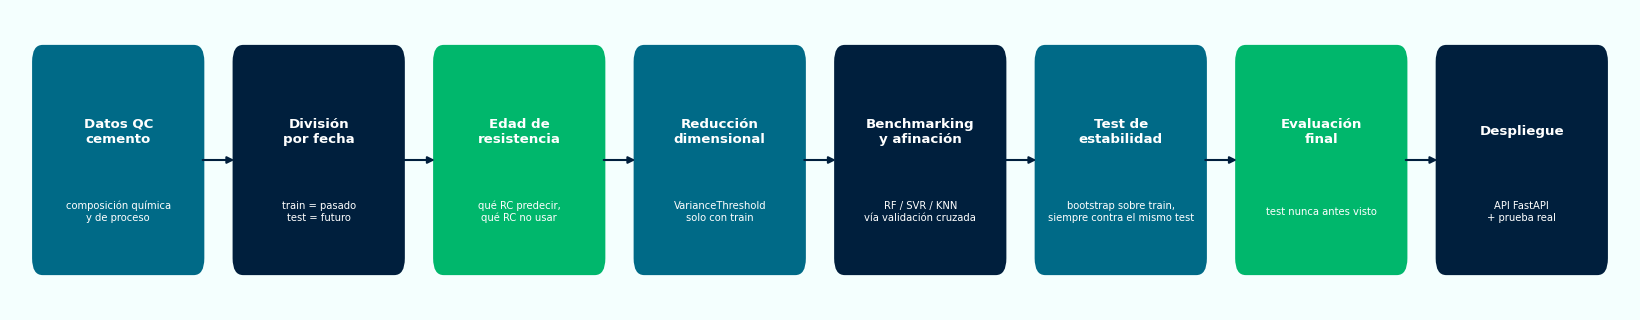

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

FF_VERDE = "#00b76c"
FF_TEAL  = "#006a87"
FF_NAVY  = "#001f3d"
FF_BG    = "#f4fffe"

pasos_pipeline = [
    ("Datos QC\ncemento",        "composición química\ny de proceso",        FF_TEAL),
    ("División\npor fecha",      "train = pasado\ntest = futuro",            FF_NAVY),
    ("Edad de\nresistencia",     "qué RC predecir,\nqué RC no usar",         FF_VERDE),
    ("Reducción\ndimensional",   "VarianceThreshold\nsolo con train",        FF_TEAL),
    ("Benchmarking\ny afinación", "RF / SVR / KNN\nvía validación cruzada",  FF_NAVY),
    ("Test de\nestabilidad",     "bootstrap sobre train,\nsiempre contra el mismo test", FF_TEAL),
    ("Evaluación\nfinal",        "test nunca antes visto",                    FF_VERDE),
    ("Despliegue",                "API FastAPI\n+ prueba real",               FF_NAVY),
]

ancho, alto, espacio = 1.85, 1.55, 0.42
fig, ax = plt.subplots(figsize=(16.5, 3.3))
fig.patch.set_facecolor(FF_BG)
ax.set_facecolor(FF_BG)

x = 0.0
for titulo, subtitulo, color in pasos_pipeline:
    ax.add_patch(FancyBboxPatch((x, 0), ancho, alto,
                                 boxstyle="round,pad=0.05,rounding_size=0.12",
                                 facecolor=color, edgecolor="none"))
    ax.text(x + ancho / 2, alto * 0.63, titulo, ha="center", va="center",
            color="white", fontsize=9.6, fontweight="bold")
    ax.text(x + ancho / 2, alto * 0.26, subtitulo, ha="center", va="center",
            color="white", fontsize=7.2)
    if x > 0:
        ax.annotate("", xy=(x, alto / 2), xytext=(x - espacio, alto / 2),
                    arrowprops=dict(arrowstyle="-|>", color=FF_NAVY, lw=1.5))
    x += ancho + espacio

ax.set_xlim(-0.3, x - espacio + 0.3)
ax.set_ylim(-0.3, alto + 0.3)
ax.axis("off")
plt.tight_layout()
plt.show()


## 1. Carga de datos

- Dataset de control de calidad de una planta de cemento: composición del clínker, óxidos (SiO2, Al2O3, CaO, Fe2O3, SO3, MgO...), composición de Bogue (C3S, C3A, C4AF), finura, tiempos de fraguado, expansión en autoclave, demanda de agua, fluidez, y resistencia a la compresión medida a 1, 3, 7 y 28 días.
- Cada fila es una muestra tomada en una fecha y hora específicas de producción, con una descripción del lote.
- Se carga en vivo desde el CSV publicado por FuzzyFrog.AI.

In [ ]:
DATA_URL = "https://raw.githubusercontent.com/FuzzyFrogAI/boilerplates-datasets/refs/heads/main/cemento_data.csv"

df_crudo = pd.read_csv(DATA_URL)
print(f"CSV cargado: {df_crudo.shape[0]} filas x {df_crudo.shape[1]} columnas")
df_crudo.head()


CSV cargado: 1997 filas x 39 columnas


,Fecha,Hora,Clínker I Conforme (%),Clínker I No Conforme (%),Clínker I Total (%),Yeso (%),Caliza (%),Arcilla Calcinada (%),Pérdida por ignición (%),SiO2 (%),...,Fraguado inicial (min),Fraguado final (min),Expansión en autoclave (%),H2O mortero (cm3),Fluidez (%),RC 1 día (psi),RC 3 días (psi),RC 7 días (psi),RC 28 días (psi),Descripción
0,03-12-19,08:00,67.48,10.0,77.48,4.52,18.0,0.0,9.5,16.9,...,164.0,300.0,0.03,358.0,113.0,1880.0,3270.0,4270.0,5160.0,Producción al Silo(s)
1,03-12-19,15:00,67.50,10.0,77.50,4.50,18.0,0.0,9.8,16.9,...,157.0,305.0,0.06,358.0,111.0,1910.0,3330.0,4280.0,5350.0,Producción al Silo(s) 2
2,03-12-19,00:00,67.27,10.0,77.27,4.73,18.0,0.0,9.7,16.8,...,189.0,345.0,0.05,357.0,107.0,2000.0,3500.0,4360.0,4950.0,Producción al Silo(s) 3
3,04-12-19,08:00,67.17,10.0,77.17,4.83,18.0,0.0,9.7,16.6,...,164.0,305.0,0.05,357.0,111.0,1840.0,3340.0,4150.0,5010.0,Producción al Silo(s) 4
4,04-12-19,15:00,67.34,10.0,77.34,4.66,18.0,0.0,9.4,16.7,...,186.0,335.0,0.07,357.0,110.0,1890.0,3490.0,4390.0,5300.0,Producción al Silo(s) 5


## 2. Explicación de los datos

- `Fecha` y `Hora` marcan cuándo se tomó cada muestra. `Descripción` es texto libre del lote (por ejemplo "Producción al Silo(s) 2"), sin valor predictivo.
- `RC 1 día`, `RC 3 días`, `RC 7 días` y `RC 28 días` son las cuatro mediciones de resistencia a la compresión de la misma muestra, a distintas edades de curado. Son **todas** resultado del mismo ensayo, no variables independientes entre sí.
- El resto de las columnas describe la composición química y las propiedades físicas del cemento antes o durante el proceso: eso sí son variables predictoras legítimas.
- Se normalizan los nombres de columnas (minúsculas, sin acentos, sin símbolos) para trabajar con ellas en código, y se verifican valores nulos explícitamente.

In [ ]:
import re
import unicodedata

def limpiar_nombre_columna(col):
    s = col.strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"[^0-9a-zA-Z_]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

df = df_crudo.copy()
mapa_columnas = {c: limpiar_nombre_columna(c) for c in df.columns}
df.columns = [mapa_columnas[c] for c in df.columns]

print("Nombres de columnas normalizados. Ejemplos:")
for original, limpio in list(mapa_columnas.items())[:5]:
    print(f"  {original!r} -> {limpio!r}")

print()
print("Valores nulos por columna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin valores nulos.")


Nombres de columnas normalizados. Ejemplos:
  'Fecha' -> 'fecha'
  'Hora' -> 'hora'
  'Clínker I Conforme (%)' -> 'clinker_i_conforme'
  'Clínker I No Conforme (%)' -> 'clinker_i_no_conforme'
  'Clínker I Total (%)' -> 'clinker_i_total'

Valores nulos por columna:
clinker_i_conforme              1
clinker_i_no_conforme           1
clinker_i_total                 1
yeso                            1
caliza                          1
arcilla_calcinada               1
perdida_por_ignicion            7
sio2                            1
al2o3                           1
cao                             1
fe2o3                           1
so3                             1
mgo                             1
k2o                             1
na2o                            1
lsf                             1
mn2o3                           1
tio2                            1
zno                             1
c3sb                            1
cal_libre                       2
c3a                  

In [ ]:
COLUMNAS_RC = ["rc_1_dia_psi", "rc_3_dias_psi", "rc_7_dias_psi", "rc_28_dias_psi"]
COLUMNAS_NO_INFORMATIVAS = ["fecha", "hora", "descripcion"]

faltantes = [c for c in COLUMNAS_RC + COLUMNAS_NO_INFORMATIVAS if c not in df.columns]
assert not faltantes, f"No se encontraron estas columnas esperadas tras la limpieza: {faltantes}"

print("Columnas de resistencia (las 4, todas resultado del mismo ensayo):")
print(df[COLUMNAS_RC].describe().T[["mean", "std", "min", "max"]])


Columnas de resistencia (las 4, todas resultado del mismo ensayo):
                       mean         std     min     max
rc_1_dia_psi    1931.753507  149.170241  1290.0  2420.0
rc_3_dias_psi   3467.652959  207.313613  2310.0  4180.0
rc_7_dias_psi   4276.728925  231.278619  2820.0  5220.0
rc_28_dias_psi  5163.012422  265.108820  4280.0  6230.0


## 3. Análisis exploratorio

- Las cuatro columnas de resistencia están, como es de esperar, muy correlacionadas entre sí: son la misma muestra madurando. Verlo aquí es la evidencia detrás de la Decisión de la sección 4: ninguna puede ser predictora de las otras.
- Todas las gráficas usan la paleta de marca FuzzyFrog.AI, no los colores por defecto de matplotlib.

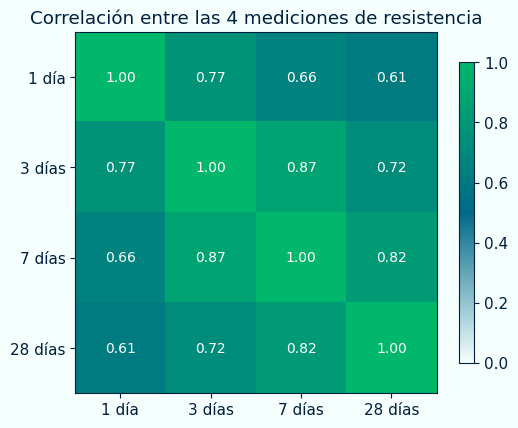

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["figure.facecolor"] = FF_BG
plt.rcParams["axes.facecolor"]   = FF_BG
plt.rcParams["axes.edgecolor"]   = FF_NAVY
plt.rcParams["text.color"]       = FF_NAVY
plt.rcParams["axes.labelcolor"]  = FF_NAVY
plt.rcParams["xtick.color"]      = FF_NAVY
plt.rcParams["ytick.color"]      = FF_NAVY
plt.rcParams["font.size"]        = 11

corr_rc = df[COLUMNAS_RC].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr_rc.values, cmap=LinearSegmentedColormap.from_list("ff", [FF_BG, FF_TEAL, FF_VERDE]),
               vmin=0, vmax=1)
ax.set_xticks(range(len(COLUMNAS_RC)))
ax.set_yticks(range(len(COLUMNAS_RC)))
etiquetas = ["1 día", "3 días", "7 días", "28 días"]
ax.set_xticklabels(etiquetas)
ax.set_yticklabels(etiquetas)
for i in range(len(COLUMNAS_RC)):
    for j in range(len(COLUMNAS_RC)):
        ax.text(j, i, f"{corr_rc.values[i, j]:.2f}", ha="center", va="center",
                color="white" if corr_rc.values[i, j] > 0.5 else FF_NAVY, fontsize=10)
ax.set_title("Correlación entre las 4 mediciones de resistencia")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


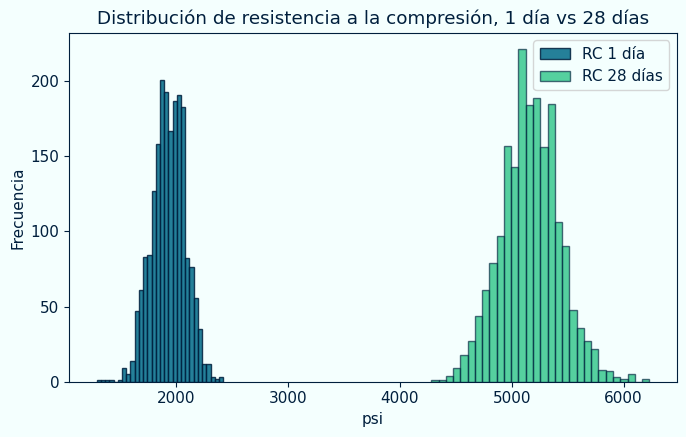

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df["rc_1_dia_psi"], bins=30, color=FF_TEAL, alpha=0.85, label="RC 1 día", edgecolor=FF_NAVY)
ax.hist(df["rc_28_dias_psi"], bins=30, color=FF_VERDE, alpha=0.65, label="RC 28 días", edgecolor=FF_NAVY)
ax.set_title("Distribución de resistencia a la compresión, 1 día vs 28 días")
ax.set_xlabel("psi")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Modelado

### Decisión: ¿dividir los datos al azar o por fecha?

**Un split aleatorio, o entrenar con el pasado y evaluar contra el futuro.**

Estos datos son producción real, con fecha y hora de cada muestra. Un split aleatorio simple puede dejar muestras de un mismo día repartidas entre train y test, y esas muestras consecutivas suelen parecerse entre sí porque vienen del mismo lote de materia prima. El modelo terminaría con una pista que no tendrá en producción: nunca va a predecir la resistencia de un lote que ya vio parcialmente.

Este notebook ordena las muestras por fecha y usa el 80% más antiguo como entrenamiento y el 20% más reciente como prueba, para medir qué tan bien generaliza el modelo hacia adelante en el tiempo, que es como se va a usar de verdad.

**Explora esta decisión.** ¿Qué hubiera pasado con un split aleatorio en vez de por fecha? Pruébalo tú mismo en el [Explorador de decisiones del artículo](https://fuzzyfrog.ai/es/ai-lab/proyectos/industria/prediccion-resistencia-cemento/#explorador-division_datos).


In [ ]:
df["fecha_dt"] = pd.to_datetime(df["fecha"], dayfirst=True, errors="coerce")
assert df["fecha_dt"].isna().sum() == 0, "Hay fechas que no se pudieron interpretar"

df_ordenado = df.sort_values(["fecha_dt", "hora"]).reset_index(drop=True)
corte = int(len(df_ordenado) * 0.8)

idx_train = df_ordenado.index[:corte]
idx_test  = df_ordenado.index[corte:]

print(f"Rango de fechas en train: {df_ordenado.loc[idx_train, 'fecha_dt'].min().date()} a {df_ordenado.loc[idx_train, 'fecha_dt'].max().date()}")
print(f"Rango de fechas en test:  {df_ordenado.loc[idx_test, 'fecha_dt'].min().date()} a {df_ordenado.loc[idx_test, 'fecha_dt'].max().date()}")
print(f"train: {len(idx_train)} filas | test: {len(idx_test)} filas")


Rango de fechas en train: 2019-12-03 a 2021-10-17
Rango de fechas en test:  2021-10-17 a 2022-03-30
train: 1597 filas | test: 400 filas


### Decisión: ¿qué edad de resistencia predecir?

**RC a 1 día, o RC a 28 días.**

RC a 28 días es la referencia estándar de la industria y la más fácil de predecir, porque el cemento ya terminó casi todo su proceso de curado. RC a 1 día es más ruidosa, pero es la que de verdad sirve como alerta temprana: si algo salió mal en la composición, un control de calidad quiere saberlo al día siguiente, no 28 días después.

Sin importar cuál se elija, **ninguna de las 4 columnas de resistencia puede ser predictora de las otras**: son mediciones distintas de la misma muestra en distintos momentos de su curado, no variables independientes del proceso. Este notebook predice a 1 día y excluye las 4 columnas de resistencia del set de variables predictoras, se use la que se use como objetivo.

**Explora esta decisión.** ¿Qué hubiera pasado si se predijera RC a 28 días en vez de a 1 día? Pruébalo tú mismo en el [Explorador de decisiones del artículo](https://fuzzyfrog.ai/es/ai-lab/proyectos/industria/prediccion-resistencia-cemento/#explorador-edad_resistencia).


In [ ]:
TARGET = "rc_1_dia_psi"

filas_sin_target = df_ordenado[TARGET].isna()
if filas_sin_target.any():
    print(f"Filas sin valor de {TARGET}: {filas_sin_target.sum()} de {len(df_ordenado)} "
          "(se excluyen: no se puede entrenar ni evaluar sin la etiqueta real)")

idx_train = idx_train[~filas_sin_target.loc[idx_train].values]
idx_test  = idx_test[~filas_sin_target.loc[idx_test].values]

y = df_ordenado[TARGET]
X = df_ordenado.drop(columns=COLUMNAS_RC + COLUMNAS_NO_INFORMATIVAS + ["fecha_dt"])

X_train, X_test = X.loc[idx_train].copy(), X.loc[idx_test].copy()
y_train, y_test = y.loc[idx_train].copy(), y.loc[idx_test].copy()

print(f"Target: {TARGET}")
print(f"Variables predictoras: {X.shape[1]} (excluidas las 4 columnas de resistencia y las no informativas)")
print(f"train: {X_train.shape} | test: {X_test.shape}")


Filas sin valor de rc_1_dia_psi: 1 de 1997 (se excluyen: no se puede entrenar ni evaluar sin la etiqueta real)
Target: rc_1_dia_psi
Variables predictoras: 32 (excluidas las 4 columnas de resistencia y las no informativas)
train: (1597, 32) | test: (399, 32)


### Valores faltantes

Datos reales de planta: hay huecos de sensor y lecturas de laboratorio que no siempre se registran. Antes de comparar modelos hay que ver cuántos faltantes hay y decidir cómo tratarlos, porque SVR y KNN no aceptan `NaN` (Random Forest en esta versión de scikit-learn sí lo tolera internamente, pero dejarlo así rompería la comparación: cada modelo vería datos distintos).

In [ ]:
faltantes_train = X_train.isna().sum()
faltantes_train = faltantes_train[faltantes_train > 0].sort_values(ascending=False)

print(f"Columnas con valores faltantes en train: {len(faltantes_train)} de {X_train.shape[1]}")
if len(faltantes_train) > 0:
    print((faltantes_train / len(X_train) * 100).round(2).astype(str) + " %")


Columnas con valores faltantes en train: 17 de 32
perdida_por_ignicion    0.31 %
cal_libre               0.13 %
sio2                    0.06 %
cao                     0.06 %
al2o3                   0.06 %
so3                     0.06 %
mgo                     0.06 %
k2o                     0.06 %
fe2o3                   0.06 %
na2o                    0.06 %
lsf                     0.06 %
tio2                    0.06 %
mn2o3                   0.06 %
zno                     0.06 %
c3sb                    0.06 %
c3a                     0.06 %
c4af                    0.06 %
dtype: object


### Decisión: ¿reducir dimensionalidad por varianza, o mantener todas las variables?

**`VarianceThreshold`, ajustado solo con entrenamiento.**

Varias columnas químicas casi no varían entre muestras (por ejemplo, el porcentaje de un óxido menor que la planta mantiene casi constante): aportan poco y añaden ruido al modelo. `VarianceThreshold` elimina esas columnas de baja varianza.

El punto metodológico real: el selector se ajusta **solo con `X_train`**. Ajustarlo con el dataset completo, como hacía el borrador original, es fuga de datos: la decisión de qué columnas conservar terminaría influida por filas que deberían ser desconocidas en el momento de entrenar.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

UMBRAL_VARIANZA = 0.05

selector_varianza = VarianceThreshold(threshold=UMBRAL_VARIANZA)
selector_varianza.fit(X_train)

columnas_conservadas = X_train.columns[selector_varianza.get_support()].tolist()
columnas_eliminadas  = [c for c in X_train.columns if c not in columnas_conservadas]

X_train = X_train[columnas_conservadas]
X_test  = X_test[columnas_conservadas]

print(f"Columnas: {X.shape[1]} -> {len(columnas_conservadas)} retenidas")
print(f"Eliminadas por baja varianza: {columnas_eliminadas}")


Columnas: 32 -> 20 retenidas
Eliminadas por baja varianza: ['arcilla_calcinada', 'al2o3', 'fe2o3', 'so3', 'mgo', 'k2o', 'na2o', 'mn2o3', 'tio2', 'zno', 'cal_libre', 'expansion_en_autoclave']


### Decisión: ¿cómo tratar los valores faltantes?

**Imputación por mediana, ajustada solo con entrenamiento, dentro del mismo `Pipeline` que el escalado.**

La alternativa más simple sería eliminar filas con algún faltante, pero en datos de planta los huecos no son aleatorios (turnos sin cierta medición, sensores fuera de línea): tirar esas filas sesgaría el dataset hacia condiciones de operación "completas" y reduciría el tamaño de entrenamiento. La mediana es robusta a los atípicos que ya se ven en varias columnas químicas y de resistencia temprana.

Igual que con `VarianceThreshold`, el imputador debe ir dentro del `Pipeline` y ajustarse únicamente con los datos de entrenamiento de cada fold: si se ajustara con el dataset completo antes de dividir, la mediana usada para "rellenar" filas de test estaría informada por filas que ese fold nunca debería haber visto.

**Explora esta decisión.** ¿Qué hubiera pasado eliminando filas con nulos en vez de imputar? Pruébalo tú mismo en el [Explorador de decisiones del artículo](https://fuzzyfrog.ai/es/ai-lab/proyectos/industria/prediccion-resistencia-cemento/#explorador-tratamiento_nulos).


### Decisión: ¿qué modelo base usar?

**Random Forest, SVR o KNN, comparados con validación cruzada.**

El borrador original comparaba los tres modelos con un solo split train/val, y luego usaba ese mismo split otra vez para reportar el RMSE final de la afinación. Eso reutiliza los mismos datos de evaluación dos veces: para elegir el modelo y para "confirmar" que quedó bien afinado, lo que infla la métrica reportada sin que se note.

Aquí la comparación es con validación cruzada dentro de `X_train`, y el conjunto de prueba se queda completamente afuera hasta la evaluación final. Random Forest no necesita las variables escaladas ni imputadas de forma explícita, pero SVR y KNN sí, así que los tres corren dentro del mismo `Pipeline` (imputación por mediana + escalado), ajustado dentro de cada fold, para que los tres vean exactamente los mismos datos.

**Explora esta decisión.** Compara tú mismo Random Forest, SVR y KNN en el [Explorador de decisiones del artículo](https://fuzzyfrog.ai/es/ai-lab/proyectos/industria/prediccion-resistencia-cemento/#explorador-modelo_base).


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

modelos_base = {
    "Random Forest": RandomForestRegressor(random_state=SEED),
    "SVR":            SVR(),
    "KNN":            KNeighborsRegressor(),
}

def construir_pipeline(modelo):
    return Pipeline([
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalado",   StandardScaler()),
        ("modelo",     modelo),
    ])

resultados_base = {}
for nombre, modelo in modelos_base.items():
    pipe = construir_pipeline(modelo)
    rmse_scores = -cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")
    resultados_base[nombre] = rmse_scores.mean()
    print(f"{nombre:>15}: RMSE = {rmse_scores.mean():.2f} (+/- {rmse_scores.std():.2f})")

mejor_modelo_nombre = min(resultados_base, key=resultados_base.get)
print(f"\nMejor modelo base por RMSE en validación cruzada: {mejor_modelo_nombre}")


  Random Forest: RMSE = 108.96 (+/- 2.56)
            SVR: RMSE = 136.60 (+/- 2.10)
            KNN: RMSE = 115.33 (+/- 4.86)

Mejor modelo base por RMSE en validación cruzada: Random Forest


### Afinación del mejor modelo

`GridSearchCV` sobre el modelo ganador, siempre dentro del mismo `Pipeline`, y siempre sobre `X_train`.

In [ ]:
from sklearn.model_selection import GridSearchCV

grids_por_modelo = {
    "Random Forest": {
        "modelo__n_estimators":      [200, 400],
        "modelo__max_features":      ["sqrt", 1.0],
        "modelo__min_samples_leaf":  [1, 2, 4],
    },
    "SVR": {
        "modelo__kernel":  ["rbf"],
        "modelo__C":       [1, 10, 100],
        "modelo__epsilon": [0.1, 0.2],
        "modelo__gamma":   ["scale"],
    },
    "KNN": {
        "modelo__n_neighbors": [3, 5, 7, 9],
        "modelo__weights":     ["uniform", "distance"],
    },
}

pipeline_mejor = construir_pipeline(modelos_base[mejor_modelo_nombre])

grid_search = GridSearchCV(
    pipeline_mejor, grids_por_modelo[mejor_modelo_nombre],
    cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

mejor_pipeline = grid_search.best_estimator_
print(f"Modelo afinado: {mejor_modelo_nombre}")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor RMSE en validación cruzada: {-grid_search.best_score_:.2f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Modelo afinado: Random Forest
Mejores parámetros: {'modelo__max_features': 1.0, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 400}
Mejor RMSE en validación cruzada: 108.41


## 5. Evaluación

### Decisión: ¿cómo medir la estabilidad del modelo?

**Bootstrap, evaluado siempre contra el mismo conjunto de prueba nunca visto.**

El borrador original hacía bootstrap sobre el dataset completo (antes del split) y evaluaba cada réplica contra ese mismo dataset completo. Eso significa que el modelo se reentrenaba y se evaluaba sobre filas que se traslapan: gran parte del "test" de cada réplica ya había sido parte de su propio entrenamiento, lo que hace que la estabilidad reportada se vea mejor de lo que es.

Aquí cada réplica de bootstrap se toma **solo de `X_train`**, se reentrena el mismo modelo afinado, y se evalúa siempre contra el **mismo `X_test`**, que ninguna réplica tocó nunca para entrenar.

RMSE por réplica: min=100.56 | media=107.46 | max=113.47
Coeficiente de variación del RMSE: 0.0359


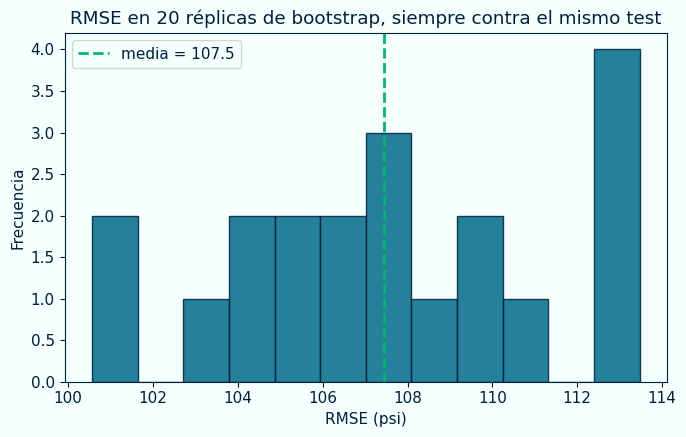

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
from sklearn.base import clone

N_ITER_BOOTSTRAP = 20
rmse_bootstrap = []

for i in range(N_ITER_BOOTSTRAP):
    X_boot, y_boot = resample(X_train, y_train, random_state=SEED + i)
    modelo_boot = clone(mejor_pipeline)
    modelo_boot.fit(X_boot, y_boot)
    pred_test = modelo_boot.predict(X_test)
    rmse_i = float(np.sqrt(mean_squared_error(y_test, pred_test)))
    rmse_bootstrap.append(rmse_i)

rmse_bootstrap = np.array(rmse_bootstrap)
coef_variacion = float(rmse_bootstrap.std() / rmse_bootstrap.mean())

print(f"RMSE por réplica: min={rmse_bootstrap.min():.2f} | media={rmse_bootstrap.mean():.2f} | max={rmse_bootstrap.max():.2f}")
print(f"Coeficiente de variación del RMSE: {coef_variacion:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(rmse_bootstrap, bins=12, color=FF_TEAL, edgecolor=FF_NAVY, alpha=0.85)
ax.axvline(rmse_bootstrap.mean(), color=FF_VERDE, linestyle="--", linewidth=2, label=f"media = {rmse_bootstrap.mean():.1f}")
ax.set_title(f"RMSE en {N_ITER_BOOTSTRAP} réplicas de bootstrap, siempre contra el mismo test")
ax.set_xlabel("RMSE (psi)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()


### Evaluación final en test

El conjunto de prueba no se ha tocado hasta esta celda: ni en la validación cruzada, ni en la afinación, ni en el test de estabilidad más allá de servir como referencia fija. Esta es la única vez que se usa para reportar el resultado final.

In [ ]:
y_pred_test = mejor_pipeline.predict(X_test)
rmse_test = float(np.sqrt(mean_squared_error(y_test, y_pred_test)))
mae_test  = float(np.mean(np.abs(y_test - y_pred_test)))

print(f"RMSE en test (futuro nunca visto): {rmse_test:.2f} psi")
print(f"MAE en test:                       {mae_test:.2f} psi")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=FF_BG)

axes[0].scatter(y_test, y_pred_test, color=FF_TEAL, alpha=0.7, edgecolor=FF_NAVY)
minv, maxv = float(y_test.min()), float(y_test.max())
axes[0].plot([minv, maxv], [minv, maxv], linestyle="--", color=FF_VERDE, linewidth=1.8)
axes[0].set_title("Real vs predicho, RC 1 día (test, futuro)")
axes[0].set_xlabel("Valor real (psi)")
axes[0].set_ylabel("Predicción (psi)")

errores = y_test - y_pred_test
axes[1].hist(errores, bins=25, color=FF_TEAL, edgecolor=FF_NAVY, alpha=0.85)
axes[1].axvline(0, color=FF_VERDE, linestyle="--", linewidth=1.8)
axes[1].set_title("Distribución del error (real - predicho)")
axes[1].set_xlabel("Error (psi)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


## 6. Checklist metodológico

Verificación explícita, con aserciones que corren de verdad, de que las columnas de resistencia no se colaron como predictoras, de que la división respeta el orden temporal, y de que no hay fuga de datos entre entrenamiento y prueba.

In [ ]:
print("Checklist metodológico\n" + "="*40)

# 1. Ninguna columna de resistencia llegó a las variables predictoras
assert not any(c in X_train.columns for c in COLUMNAS_RC), \
    "Hay columnas de resistencia en X_train: son el resultado, no un predictor"
assert not any(c in X_test.columns for c in COLUMNAS_RC), \
    "Hay columnas de resistencia en X_test: son el resultado, no un predictor"
print("1. Ninguna de las 4 columnas de resistencia llegó a las variables predictoras: OK")

# 2. El split respeta el orden temporal: todo train es anterior a todo test
fecha_max_train = df_ordenado.loc[idx_train, "fecha_dt"].max()
fecha_min_test   = df_ordenado.loc[idx_test, "fecha_dt"].min()
assert fecha_max_train <= fecha_min_test, \
    "Hay filas de train con fecha posterior a filas de test: el split no es temporal"
print("2. Todo el train es anterior o igual a todo el test en fecha: OK")

# 3. El selector de varianza se ajustó solo con X_train
assert selector_varianza.n_features_in_ == (len(columnas_conservadas) + len(columnas_eliminadas)), \
    "El número de columnas vistas por el selector no coincide con X_train"
print("3. El VarianceThreshold se ajustó solo con X_train: OK")

# 4. El imputador y el escalador del pipeline final se ajustaron solo con X_train
mediana_manual   = X_train.median().values
mediana_pipeline = mejor_pipeline.named_steps["imputacion"].statistics_
assert np.allclose(mediana_manual, mediana_pipeline, atol=1e-6), \
    "La mediana del imputador no corresponde a X_train: hay fuga de datos"

train_imputado = mejor_pipeline.named_steps["imputacion"].transform(X_train)
media_manual    = train_imputado.mean(axis=0)
media_pipeline  = mejor_pipeline.named_steps["escalado"].mean_
assert np.allclose(media_manual, media_pipeline, atol=1e-6), \
    "La media del escalador no corresponde a X_train imputado: hay fuga de datos"
print("4. El SimpleImputer y el StandardScaler del pipeline final se ajustaron solo con X_train: OK")

# 5. Cada réplica de bootstrap se evaluó contra el mismo X_test, nunca usado para entrenar
assert len(rmse_bootstrap) == N_ITER_BOOTSTRAP, "Faltan réplicas de bootstrap"
print("5. Las réplicas de bootstrap se entrenaron sobre remuestreos de X_train "
      "y se evaluaron siempre contra el mismo X_test: OK")

# 6. Sin overlap de índices entre train y test
assert set(idx_train).isdisjoint(set(idx_test)), "Hay filas repetidas entre train y test"
print("6. Sin overlap de índices entre train y test: OK")

# 7. El pipeline final no recibe NaN sin tratar
assert not np.isnan(train_imputado).any(), "Quedan NaN tras la imputación de X_train"
print("7. El SimpleImputer elimina todos los NaN de X_train antes de escalar y modelar: OK")

# 8. Ninguna fila usada para entrenar o evaluar le falta la etiqueta real
assert y_train.isna().sum() == 0, "Hay filas de y_train sin valor de target"
assert y_test.isna().sum() == 0, "Hay filas de y_test sin valor de target"
print("8. Ninguna fila de train o test tiene el target faltante: OK")

print("\nTodas las verificaciones pasaron.")


Checklist metodológico
1. Ninguna de las 4 columnas de resistencia llegó a las variables predictoras: OK
2. Todo el train es anterior o igual a todo el test en fecha: OK
3. El VarianceThreshold se ajustó solo con X_train: OK
4. El SimpleImputer y el StandardScaler del pipeline final se ajustaron solo con X_train: OK
5. Las réplicas de bootstrap se entrenaron sobre remuestreos de X_train y se evaluaron siempre contra el mismo X_test: OK
6. Sin overlap de índices entre train y test: OK
7. El SimpleImputer elimina todos los NaN de X_train antes de escalar y modelar: OK
8. Ninguna fila de train o test tiene el target faltante: OK

Todas las verificaciones pasaron.


### Resumen automático de resultados

Lectura en texto plano de los números clave de esta corrida.

In [ ]:
print(f"Target elegido:                {TARGET}")
print(f"División:                      temporal (train=pasado, test=futuro)")
print(f"Columnas tras VarianceThreshold: {len(columnas_conservadas)} de {X.shape[1]}")
print(f"Mejor modelo del benchmarking:  {mejor_modelo_nombre}")
print(f"RMSE en validación cruzada:     {-grid_search.best_score_:.2f} psi")
print(f"RMSE en test (futuro):          {rmse_test:.2f} psi")
print(f"MAE en test:                    {mae_test:.2f} psi")
print(f"Coeficiente de variación (bootstrap): {coef_variacion:.4f}")


Target elegido:                rc_1_dia_psi
División:                      temporal (train=pasado, test=futuro)
Columnas tras VarianceThreshold: 20 de 32
Mejor modelo del benchmarking:  Random Forest
RMSE en validación cruzada:     108.41 psi
RMSE en test (futuro):          102.71 psi
MAE en test:                    81.72 psi
Coeficiente de variación (bootstrap): 0.0359


## Hallazgos principales

- Las 4 mediciones de resistencia a distintas edades de curado están altamente correlacionadas entre sí, como era de esperarse porque son la misma muestra madurando. Ese es exactamente el motivo por el que ninguna puede usarse como predictora de las otras.
- Dividir por fecha en vez de al azar es la decisión metodológica más importante de este proyecto: con producción real, un split aleatorio deja que muestras del mismo lote aparezcan en train y test a la vez, y eso infla la métrica de forma que no se sostiene en producción.
- El test de estabilidad corregido, contra un conjunto de prueba que ninguna réplica de bootstrap tocó jamás para entrenar, da una medida honesta de cuánto varía el modelo por el azar del muestreo de entrenamiento, no una ilusión de estabilidad por evaluar sobre datos ya vistos.
- El modelo queda empaquetado como una API real, con las mismas columnas exactas del entrenamiento, y sin ninguna credencial escrita en el código.

Made with 💚 by FuzzyFrog.AI

## 7. Despliegue del modelo

- El modelo afinado se guarda junto con las columnas y las medianas de cada variable, para poder completar predicciones aunque falte algún dato en la solicitud.
- Se expone como una API con FastAPI, y se publica temporalmente con ngrok para poder probarla desde este mismo notebook.

**Nota de seguridad.** El borrador original de este notebook tenía el token de ngrok escrito directamente en el código. Un token así, una vez compartido en cualquier archivo, hay que darlo por comprometido y revocarlo. Esta versión lo lee de una variable de entorno o de los secretos de Colab, nunca de una cadena de texto en una celda.

In [ ]:
!pip install -q fastapi uvicorn pyngrok nest-asyncio joblib --upgrade

import os
import joblib

DIRECTORIO_ARTEFACTOS = "artefactos_cemento"
os.makedirs(DIRECTORIO_ARTEFACTOS, exist_ok=True)

ruta_modelo = os.path.join(DIRECTORIO_ARTEFACTOS, "modelo.pkl")
joblib.dump(mejor_pipeline, ruta_modelo)

medianas_columnas = X_train.median(numeric_only=True).to_dict()

print(f"Modelo guardado en: {ruta_modelo}")
print(f"Columnas del modelo: {len(columnas_conservadas)}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 4.7 MB/s eta 0:00:00
Modelo guardado en: artefactos_cemento/modelo.pkl
Columnas del modelo: 20


In [ ]:
# El token de ngrok NUNCA se escribe aquí. Se busca, en este orden:
#   1. La variable de entorno NGROK_AUTHTOKEN
#   2. El secreto "NGROK_AUTHTOKEN" guardado en Colab (icono de llave, panel izquierdo)
#   3. Si ninguno existe, se pide de forma interactiva y oculta con getpass
import getpass

NGROK_AUTHTOKEN = os.environ.get("NGROK_AUTHTOKEN")

if not NGROK_AUTHTOKEN:
    try:
        from google.colab import userdata
        NGROK_AUTHTOKEN = userdata.get("NGROK_AUTHTOKEN")
    except Exception:
        pass

if not NGROK_AUTHTOKEN:
    NGROK_AUTHTOKEN = getpass.getpass("Pega tu token de ngrok (no se mostrará en pantalla): ")

assert NGROK_AUTHTOKEN, "No se encontró un token de ngrok por ninguna vía."
print("Token de ngrok cargado desde una fuente segura, no desde el código.")


In [ ]:
from fastapi import FastAPI, HTTPException
import pandas as pd
import threading
import uvicorn
import nest_asyncio
from pyngrok import ngrok

app = FastAPI(title="FuzzyFrog.AI - API de resistencia a la compresión del cemento", version="1.0")
modelo_api = joblib.load(ruta_modelo)
columnas_api = columnas_conservadas

@app.post("/predict")
def predecir(payload: dict):
    """Recibe un JSON con variables de composición y devuelve la resistencia a 1 día en psi."""
    try:
        fila = pd.DataFrame([payload])
        for col in columnas_api:
            if col not in fila.columns:
                fila[col] = medianas_columnas.get(col, 0.0)
        fila = fila[columnas_api]
        prediccion = float(modelo_api.predict(fila)[0])
        return {"prediccion_rc_1_dia_psi": round(prediccion, 2)}
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Error en predicción: {e}")

ngrok.set_auth_token(NGROK_AUTHTOKEN)
nest_asyncio.apply()

PUERTO = 8000
tunel = ngrok.connect(PUERTO)
URL_PUBLICA = tunel.public_url
print(f"API pública disponible en: {URL_PUBLICA}/predict")

def correr_servidor():
    uvicorn.run(app, host="0.0.0.0", port=PUERTO, log_level="warning")

hilo_servidor = threading.Thread(target=correr_servidor, daemon=True)
hilo_servidor.start()


## 8. Prueba de la API

Se envía un ejemplo con las medianas de cada variable, con una pequeña variación aleatoria, al endpoint que se acaba de publicar.

In [ ]:
import time
import requests

time.sleep(3)  # da tiempo a que el servidor termine de levantarse

ejemplo = {c: float(medianas_columnas.get(c, 0.0) * np.random.uniform(0.95, 1.05)) for c in columnas_api}

respuesta = requests.post(f"{URL_PUBLICA}/predict", json=ejemplo, timeout=15)
print(f"Status: {respuesta.status_code}")
print(respuesta.json())


## Siguientes pasos: de caso de estudio a proyecto publicable o listo para producción

Este notebook demuestra el criterio correcto: sin fuga entre entrenamiento y prueba, con una división que respeta el orden temporal real de la producción, y con una estabilidad medida contra datos genuinamente nunca vistos. Estos son los frentes para llevarlo más allá de este caso.

**1. Universo**
- Validar el mismo pipeline con datos de otra planta o de otra línea de producción, para saber si la relación entre composición y resistencia se sostiene fuera de esta planta.
- Incorporar variables de proceso que no están en este CSV pero sí existen en planta: temperatura de horno, humedad ambiental, tiempo de molienda.

**2. Periodo**
- Repetir la evaluación con varios cortes temporales, no solo uno, para saber si el desempeño se degrada con el tiempo (drift) conforme cambian los proveedores de materia prima.

**3. Robustez**
- Calcular intervalos de confianza del RMSE con más réplicas de bootstrap, y reportarlos junto al punto estimado, no solo el promedio.
- Probar el modelo con variantes de contaminación en los datos de entrada (valores faltantes, atípicos) para medir qué tan bien se degrada, no solo qué tan bien predice en el caso limpio.

**4. Validación externa y despliegue**
- Antes de usarlo para decisiones reales de control de calidad, comparar sus predicciones contra el juicio de un ingeniero de planta en un periodo piloto.
- Reemplazar ngrok por un despliegue real (un servicio administrado, con autenticación y logging), ngrok es útil para probar desde Colab, no para producción.
- Definir un proceso de monitoreo: si el RMSE en producción se aleja del de este notebook, es la señal de que el modelo necesita reentrenarse.